****
**1. Install Required Libraries**
****

In [1]:
!pip install tensorflow matplotlib scikit-learn


****
**2. Mount Google Drive**
****

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


****
**3. Define Dataset Paths**
****

In [8]:
TRAIN_DIR = '/content/drive/MyDrive/chest-xray-pneumonia-detection/Dataset/chest_xray/train'
TEST_DIR  = '/content/drive/MyDrive/chest-xray-pneumonia-detection/Dataset/chest_xray/test'
VAL_DIR   = '/content/drive/MyDrive/chest-xray-pneumonia-detection/Dataset/chest_xray/val'

['NORMAL', 'PNEUMONIA']


****
**4. Verify Dataset Structure**
****

In [ ]:
import os
print(os.path.exists(TRAIN_DIR))
print(os.path.exists(TEST_DIR))
print(os.listdir(TRAIN_DIR))

****
**5. Create a Sample Dataset of 50 Images**
****

In [17]:
import os
import shutil
import random

SOURCE_TRAIN = "/content/drive/MyDrive/chest-xray-pneumonia-detection/Dataset/chest_xray/train"
TARGET = "/content/sample_dataset"

# Create folders
os.makedirs(f"{TARGET}/NORMAL", exist_ok=True)
os.makedirs(f"{TARGET}/PNEUMONIA", exist_ok=True)

# Select 25 images from each class
for cls in ["NORMAL", "PNEUMONIA"]:
    source_folder = os.path.join(SOURCE_TRAIN, cls)
    images = [img for img in os.listdir(source_folder)
              if img.lower().endswith(('.jpeg', '.jpg', '.png'))]
    selected = random.sample(images, 25)
    for img in selected:
        shutil.copy(
            os.path.join(source_folder, img),
            os.path.join(TARGET, cls, img)
        )
print("50-image dataset created successfully.")

50-image dataset created successfully.


****
**6. Verify Sample Dataset**
****


In [18]:
import os

print("NORMAL:", len(os.listdir("/content/sample_dataset/NORMAL")))
print("PNEUMONIA:", len(os.listdir("/content/sample_dataset/PNEUMONIA")))

NORMAL: 25
PNEUMONIA: 25


****
**7. Load Dataset**
****


In [19]:
import tensorflow as tf

IMG_SIZE = (224,224)
BATCH_SIZE = 8

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/sample_dataset",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/sample_dataset",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 50 files belonging to 2 classes.
Using 40 files for training.
Found 50 files belonging to 2 classes.
Using 10 files for validation.


****
**Check Dataset Size**
****

In [20]:
print("Training batches:", len(train_ds))
print("Testing batches:", len(test_ds))

Training batches: 5
Testing batches: 2


****
**9. Build CNN Model**
****


In [27]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Rescaling(1./255),

    layers.Conv2D(32,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(1,activation='sigmoid')
])

****
**10. Compile Model**
****


In [23]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully")

Model compiled successfully


****
**11. Train Model**
****


In [24]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.3750 - loss: 1.6339 - val_accuracy: 0.4000 - val_loss: 0.7401
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.6000 - loss: 0.6807 - val_accuracy: 0.6000 - val_loss: 0.6222
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 944ms/step - accuracy: 0.6250 - loss: 0.6330 - val_accuracy: 0.8000 - val_loss: 0.5572
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9250 - loss: 0.4079 - val_accuracy: 0.7000 - val_loss: 0.5982
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 920ms/step - accuracy: 0.8500 - loss: 0.2786 - val_accuracy: 0.7000 - val_loss: 0.4339
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.9250 - loss: 0.1897 - val_accuracy: 0.7000 - val_loss: 0.4794
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 920ms/step - accuracy: 0.9500 - loss: 0.1842 - val_accuracy: 0.6000 - val_loss: 0.5478
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.9750 - loss: 0.0661 - val_accuracy: 0.8000 - val_loss: 0.5132
Epoc

****
**12. Evaluate Model**
****


In [25]:
loss, accuracy = model.evaluate(test_ds)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8000 - loss: 0.7676
Test Loss: 0.7675807476043701
Test Accuracy: 0.800000011920929


****
**13. Accuracy Graph**
****


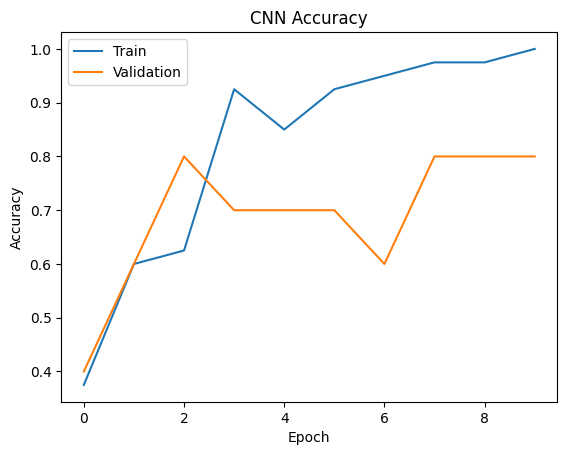

In [26]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('CNN Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])

plt.show()

****
**14. Loss Graph**
****

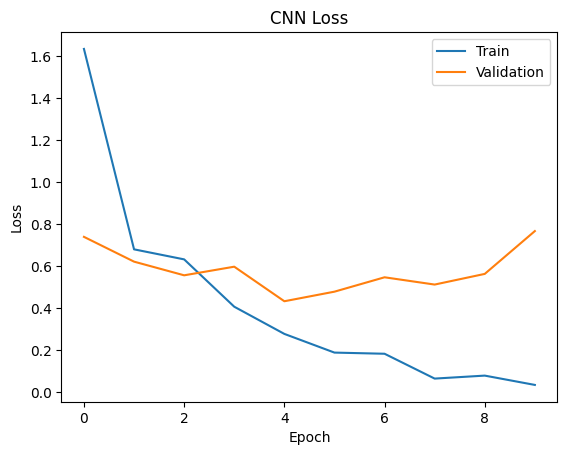

In [28]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

****
**15. Save the Model**
****

In [ ]:
model.save('cnn_pneumonia_model.h5')